In [1]:
#Import Libs
from matplotlib import pyplot as plot
import matplotlib as mpl
import urllib.request
import urllib.parse
import numpy as np
import math
import cv2

In [2]:
image_url = 'https://raw.githubusercontent.com/jrafa1607/Lego_Legal_Solution_CV/main/Dataset/img_101.jpg'

In [3]:
#Open the Image
with urllib.request.urlopen(image_url) as url:
    s = url.read()

In [4]:
#Convert to a Numpy Array and Decode with cv2
img = cv2.imdecode(np.frombuffer(s, np.uint8), -1)

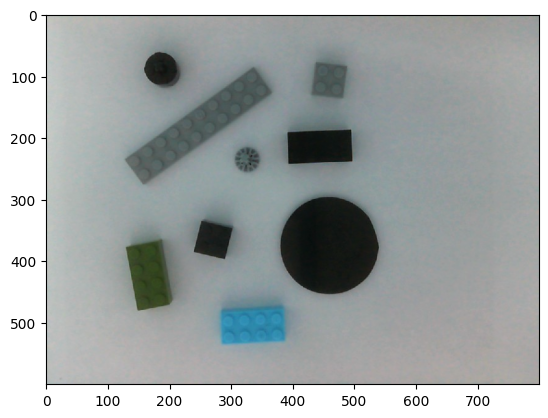

In [5]:
#Show the Image
plot.imshow(img,cmap='gray')
plot.show()

### **Table - Lego Pieces and Specifications**

| Type | Specification (Size) | Target (box) |
| :--- | :--- | :--- |
| Circ1 | 48 mm Ø | Cx_1 |
| Circ2 | 16 mm Ø | Cx_2 |
| Circ3 | 13 mm Ø | Cx_3 |
| Reta1 | 80 × 16 mm | Cx_4 |
| Reta2 | 32 × 16 mm | Cx_5 |
| Quad1 | 16 × 16 mm | Cx_6 |

In [6]:
#Split in R, G and B
B, G, R = cv2.split(img)

In [7]:
#Select the Blue Layer
img_gray = B

In [8]:
#Show the Stats
print("GrayMax: " + str(img_gray.max()))
print("GrayMin: " + str(img_gray.min()))
print("GrayMean: " + str(img_gray.mean()))

GrayMax: 209
GrayMin: 2
GrayMean: 142.29048125


### **Gamma Adjustment Mapping - File Tunning**

| Range (Mean Grayscale Value) | Gamma Value |
|:---|:---|
| 142.31 < x < 142.37 | 0.467 |
| 142.37 < x < 142.4 | 0.865 |
| 148.0 < x < 148.9 | 0.075 |
| 150.0 < x < 150.9 | 0.850 |
| 151.0 < x < 151.9 | 0.750 |
| 155.0 < x < 155.9 | 0.680 |
| 139.0 < x < 139.9 | 0.750 |
| 140.0 < x < 140.9 | 0.735 |
| 143.78 < x < 143.79 | 0.285 |
| 143.6 < x < 143.9 | 0.710 |
| 146.00 < x < 146.05 | 0.675 |
| Other | 1.015 |

In [9]:
#Gamma Adjust - File Tuning
if img_gray.mean() > 142.31 and img_gray.mean() < 142.37:
    gamma = 0.467
elif img_gray.mean() > 142.37 and img_gray.mean() < 142.4:
    gamma = 0.865
elif img_gray.mean() > 148.0 and img_gray.mean() < 148.9:
    gamma = 0.075
elif img_gray.mean() > 150.0 and img_gray.mean() < 150.9:
    gamma = 0.850
elif img_gray.mean() > 151.0 and img_gray.mean() < 151.9:
    gamma = 0.750
elif img_gray.mean() > 155.0 and img_gray.mean() < 155.9:
    gamma = 0.680
elif img_gray.mean() > 139.0 and img_gray.mean() < 139.9:
    gamma = 0.750
elif img_gray.mean() > 140.0 and img_gray.mean() < 140.9:
    gamma = 0.735
elif img_gray.mean() > 143.78 and img_gray.mean() < 143.79:
    gamma = 0.285
elif img_gray.mean() > 143.6 and img_gray.mean() < 143.9:
    gamma = 0.710
elif img_gray.mean() > 146.00 and img_gray.mean() < 146.05:
    gamma = 0.675
else:
    gamma = 1.015

In [10]:
#Show the Gamma Value
print("Gama Value: " + str(gamma))

Gama Value: 1.015


In [11]:
#Apply Gamma Transformation
input = img_gray/img_gray.max()
img_gray = input ** gamma * 255

In [12]:
#Convert to Unit8
img_gray = img_gray.astype("uint8")

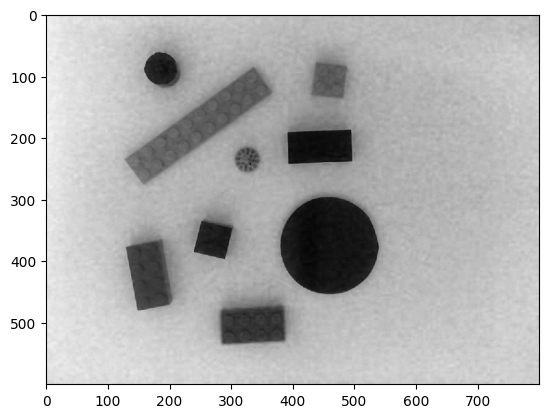

In [13]:
#Show the Results
plot.imshow(img_gray, cmap='gray')
plot.show()

In [14]:
#Add Roberts Edge
masc1 = np.array([[0, 1], [-1, 0]])
masc2 = np.array([[1, 0], [0, -1]])

img_roberts1 = cv2.filter2D(img_gray, -1, masc1)
img_roberts2 = cv2.filter2D(img_gray, -1, masc2)
img_roberts = cv2.add(img_roberts1, img_roberts2)

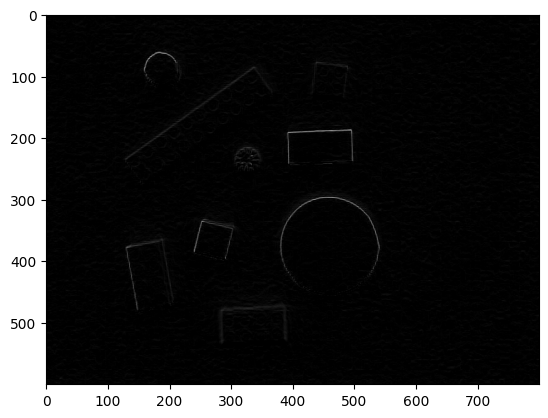

In [15]:
#Show the Edges
plot.imshow(img_roberts, cmap='gray')
plot.show()

In [16]:
#Apply Edges in the Image
img_gray = img_gray + img_roberts

In [17]:
#Apply Blur and MedianBlur in the Image
img_gray = cv2.blur(img_gray,(3,3))
img_gray = cv2.medianBlur(img_gray,3)

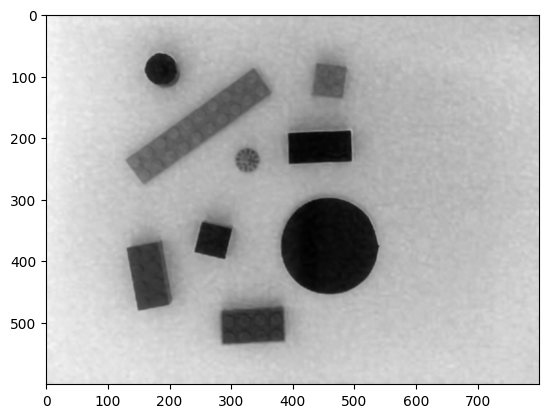

In [18]:
#Show the Results
plot.imshow(img_gray, cmap='gray')
plot.show()

In [19]:
#Apply Threshold by OTSU in the Image
otsu_threshold, img_bin = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

In [20]:
#Show the OTSU Value
print("Otsu Value: " + str(otsu_threshold))

Otsu Value: 125.0


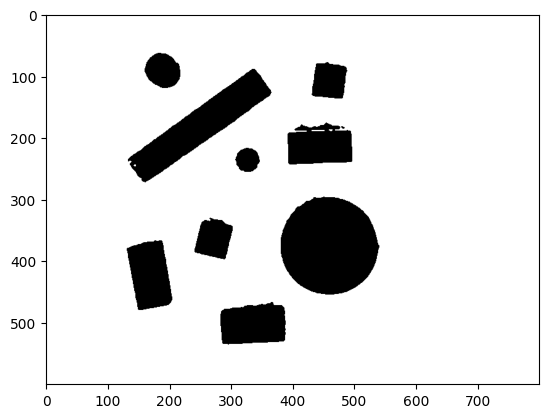

In [21]:
#Show the Results
plot.imshow(img_bin, cmap='gray')
plot.show()

In [22]:
#Change the Colors after OTSU
e = img_bin/img_gray.max()
img_bin = e.max()-e

In [23]:
#Convert to Unit8
img_bin = img_bin.astype("uint8")

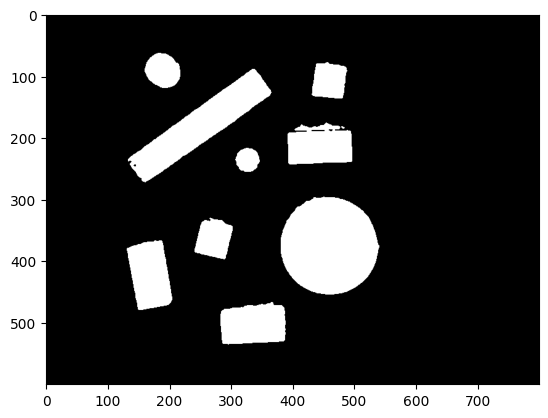

In [24]:
#Show the Results
plot.imshow(img_bin, cmap='gray')
plot.show()

In [25]:
#Identify the Connected Objects
(numCCs, imgLabels, stats, centroids) = cv2.connectedComponentsWithStats(img_bin, connectivity=8)

In [26]:
#Check the Area of the Object and Make the Classification
c = 0
for i in range (numCCs):
    if stats[i,cv2.CC_STAT_AREA] > 450:
        if i > 0:
            c = c + 1
            print("Component " + str(c) + ": Area = " + str(stats[i,cv2.CC_STAT_AREA]) + ", " +
                 str(stats[i,cv2.CC_STAT_HEIGHT]) + "x" + str(stats[i,cv2.CC_STAT_WIDTH]))

Component 1: Area = 2496, 57x58
Component 2: Area = 2771, 59x58
Component 3: Area = 12895, 184x233
Component 4: Area = 5912, 68x105
Component 5: Area = 1179, 39x40
Component 6: Area = 19774, 159x160
Component 7: Area = 3011, 68x62
Component 8: Area = 6191, 113x74
Component 9: Area = 6235, 69x106



Total de Components: 9


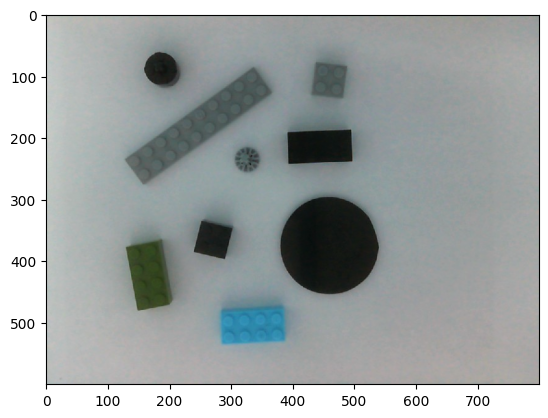

In [27]:
#Show the Totals of the Components and the Image
print("\nTotal de Components: " + str(c))
plot.imshow(img,cmap='gray')
plot.show()

In [28]:
#Initiate the Boxes Variables
circ1 = 0
circ2 = 0
circ3 = 0
reta1 = 0
reta2 = 0
quad1 = 0

In [29]:
#Make The Classification
i = 0
for i in range (numCCs):
    if stats[i,cv2.CC_STAT_AREA] > 16000 and stats[i,cv2.CC_STAT_AREA] < 22000:
        circ1 = circ1 + 1
    elif stats[i,cv2.CC_STAT_AREA] > 2000 and stats[i,cv2.CC_STAT_AREA] < 2500:
        circ2 = circ2 + 1
    elif stats[i,cv2.CC_STAT_AREA] > 800 and stats[i,cv2.CC_STAT_AREA] < 2000:
        circ3 = circ3 + 1
    elif stats[i,cv2.CC_STAT_AREA] > 8000 and stats[i,cv2.CC_STAT_AREA] < 15000:
        reta1 = reta1 + 1
    elif stats[i,cv2.CC_STAT_AREA] > 5000 and stats[i,cv2.CC_STAT_AREA] < 8000:
        reta2 = reta2 + 1
    elif stats[i,cv2.CC_STAT_AREA] > 2499 and stats[i,cv2.CC_STAT_AREA] < 3500:
        quad1 = quad1 + 1

The Component 1, [189.18349359  91.31009615] = Circ2: Cx_2 
The Component 2, [459.33273187 107.89029231] = Quad1: Cx_6 
The Component 3, [250.0064366  180.40263668] = Reta1: Cx_4 
The Component 4, [443.72259811 212.73494587] = Reta2: Cx_5 
The Component 5, [326.67345208 236.1620017 ] = Circ3: Cx_3 
The Component 6, [458.94255082 375.42358653] = Circ1: Cx_1 
The Component 7, [272.01727001 363.83493856] = Quad1: Cx_6 
The Component 8, [168.24261024 422.74220643] = Reta2: Cx_5 
The Component 9, [336.14883721 502.82357658] = Reta2: Cx_5 


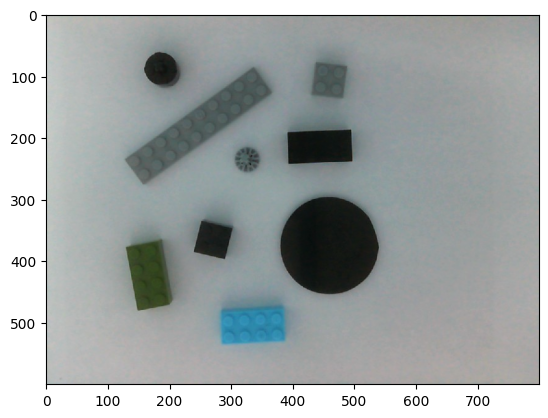

In [30]:
#Validation Phase
c = 1
for i in range (numCCs):
    if stats[i,cv2.CC_STAT_AREA] > 500:
        if i > 0:
            if stats[i,cv2.CC_STAT_AREA] > 16000 and stats[i,cv2.CC_STAT_AREA] < 22000:
                print("The Component " + str(c) + ", " + str(centroids[i]) + " = Circ1: Cx_1 ")
            if stats[i,cv2.CC_STAT_AREA] > 2000 and stats[i,cv2.CC_STAT_AREA] < 2500:
                print("The Component " + str(c) + ", " + str(centroids[i]) + " = Circ2: Cx_2 ")
            if stats[i,cv2.CC_STAT_AREA] > 800 and stats[i,cv2.CC_STAT_AREA] < 2000:
                print("The Component " + str(c) + ", " + str(centroids[i]) + " = Circ3: Cx_3 ")
            if stats[i,cv2.CC_STAT_AREA] > 8000 and stats[i,cv2.CC_STAT_AREA] < 15000:
                print("The Component " + str(c) + ", " + str(centroids[i]) + " = Reta1: Cx_4 ")
            if stats[i,cv2.CC_STAT_AREA] > 5000 and stats[i,cv2.CC_STAT_AREA] < 8000:
                print("The Component " + str(c) + ", " + str(centroids[i]) + " = Reta2: Cx_5 ")
            if stats[i,cv2.CC_STAT_AREA] > 2499 and stats[i,cv2.CC_STAT_AREA] < 3500:
                print("The Component " + str(c) + ", " + str(centroids[i]) + " = Quad1: Cx_6 ")
            c = c + 1

plot.imshow(img,cmap='gray')
plot.show()

Box 1 (Circ1 - Circulo de 48mmØ): 1
Box 2 (Circ2 - Circulo de 16mmØ): 1
Box 3 (Circ3 - Circulo de 13mmØ): 1
Box 4 (Reta1 - Retangulo de 80×16mm): 1
Box 5 (Reta2 - Retangulo de 32×16mm): 3
Box 6 (Quad1 - Quadrado de 16x16mm): 2


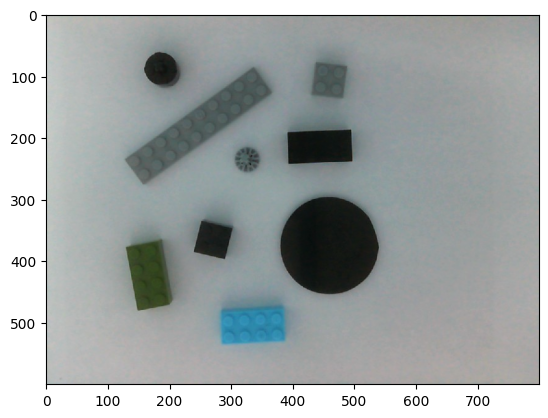

In [31]:
#Show the Classification Results
print("Box 1 (Circ1 - Circulo de 48mmØ): " + str(circ1))
print("Box 2 (Circ2 - Circulo de 16mmØ): " + str(circ2))
print("Box 3 (Circ3 - Circulo de 13mmØ): " + str(circ3))
print("Box 4 (Reta1 - Retangulo de 80×16mm): " + str(reta1))
print("Box 5 (Reta2 - Retangulo de 32×16mm): " + str(reta2))
print("Box 6 (Quad1 - Quadrado de 16x16mm): " + str(quad1))

plot.imshow(img,cmap='gray')
plot.show()